# QSK (N=20): Training (multi-QSK + multi-NQS seeds)

This notebook is part of the work: arXiv:2609.26032 [quant-ph] 
"Hyperbolic Restricted Boltzmann Machine Neural Quantum State" by HL Dao

In [1]:
import sys
sys.path.append('../../qsk_hrbm_utility')

from qsk_netket_pipeline import *
from sk import generate_hamiltonian_sk, generate_state_sk
from hrbm import *

/opt/anaconda3/envs/syk_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed_qsk_list=[1234, 4444, 5678, 6666, 9012, 9999]
seed_nqs_list = [101, 202, 303, 404, 505]

In [3]:
# number of spins
N = 20
# Common hyperparams
alpha=1
lr=0.05
n_samples = 1008
epochs=450

In [4]:
def nqs_training(N, hamiltonian, exact_E, model, lr, alpha, n_samples, seed_nqs, model_name):
    sampler = nk.sampler.MetropolisLocal(hamiltonian)    
    optimizer = optax.inject_hyperparams(optax.sgd)(learning_rate=lr)
    key_model, key_sampler, key_vstate = set_seed(seed_nqs)
    vstate = nk.vqs.MCState(sampler, model, n_samples=n_samples, seed=key_vstate)
    print("Has", vstate.n_parameters, "parameters")
    
    start = time.time()
    netket_pipeline(N, model, sampler, H, vstate, optimizer, 
                iter_num=epochs,  exact_E =exact_E,  holomorphic=False,
                log_filename=f"qsk_N={N}/seed_qsk={seed_qsk}/seed={seed_nqs}/{model_name}_alpha={alpha}_ML")
    
    end = time.time()
    print(f'Time taken = {end-start} (secs)')

## RBM

********************************************************************************
Current seed_qsk=1234
# Loaded state from  sk_20_1234.npy
Exact ED Ground State Energy for seed 1234 is -21.166380
********************************************************************************
Current seed_nqs=101
Has 440 parameters


  0%|   | 0/450 [00:03<?, ?it/s, Energy=-19.927 ± 0.070 [σ²=4.9e+00, R̂=1.009]]

Iteration 000: Energy = -19.926644, Var = 4.9209, LR = 5.00e-02


  2%| | 10/450 [00:01<00:46,  9.53it/s, Energy=-21.069 ± 0.018 [σ²=3.4e-01, R̂=

Iteration 010: Energy = -21.078543, Var = 0.3691, LR = 5.00e-02


...

Iteration 120: Energy = -21.155197, Var = 0.0588, LR = 1.25e-02


 29%|▎| 132/450 [00:14<00:27, 11.69it/s, Energy=-21.1492 ± 0.0074 [σ²=5.5e-02, 

Iteration 130: Energy = -21.156506, Var = 0.0585, LR = 1.25e-02

 >>> [LR REDUCTION] Step 130: Energy stalled at -21.156506
 >>> Lowering LR: 1.25e-02 --> 6.25e-03



 31%|▎| 140/450 [00:14<00:33,  9.38it/s, Energy=-21.1611 ± 0.0075 [σ²=5.7e-02, 


Iteration 140: Energy = -21.161107, Var = 0.0569, LR = 6.25e-03

 >>> [EARLY STOPPING] Step 140: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 040 (Energy: -21.173753)...


Restored best model weights from step 040 (Energy: -21.173753)

Relative error   : 0.0003483351427433497

Mean Energy:        -21.157407
Error Bar:          ± 0.011486
Variance:           0.132992
Final VMC Energy:   -21.161107
Energy per Fermion: -1.057870
Final model weights saved to: qsk_N=20/seed_qsk=1234/seed=101/rbm_alpha=1_ML_final_params.mpack


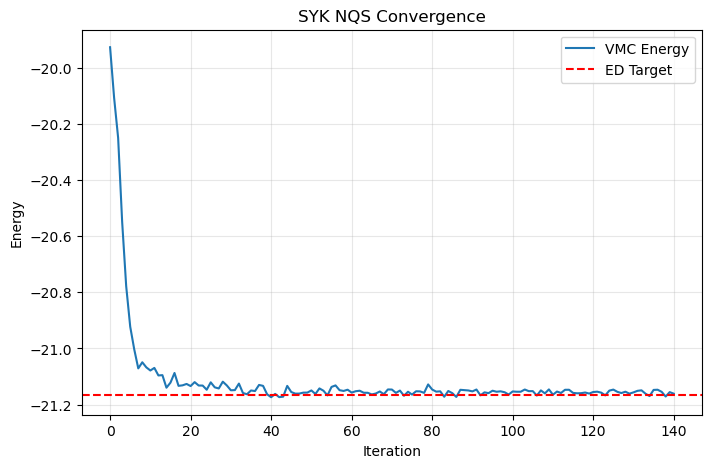

Time taken = 21.378252029418945 (secs)
Current seed_nqs=202
Has 440 parameters


  0%|   | 0/450 [00:00<?, ?it/s, Energy=-19.961 ± 0.070 [σ²=4.9e+00, R̂=1.014]]

Iteration 000: Energy = -19.960669, Var = 4.9057, LR = 5.00e-02


  3%| | 12/450 [00:01<00:39, 11.07it/s, Energy=-21.121 ± 0.019 [σ²=3.8e-01, R̂=

Iteration 010: Energy = -21.077739, Var = 0.3906, LR = 5.00e-02


...


 >>> [LR REDUCTION] Step 163: Energy stalled at -21.164862
 >>> Lowering LR: 1.25e-02 --> 6.25e-03



 38%|▍| 172/450 [00:15<00:22, 12.36it/s, Energy=-21.1596 ± 0.0063 [σ²=4.0e-02, 

Iteration 170: Energy = -21.159709, Var = 0.0437, LR = 6.25e-03


 38%|▍| 173/450 [00:15<00:24, 11.34it/s, Energy=-21.1646 ± 0.0068 [σ²=4.6e-02, 



 >>> [EARLY STOPPING] Step 173: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 073 (Energy: -21.178916)...


Restored best model weights from step 073 (Energy: -21.178916)

Relative error   : 0.0005922588502205612

Mean Energy:        -21.161913
Error Bar:          ± 0.009142
Variance:           0.084249
Final VMC Energy:   -21.164633
Energy per Fermion: -1.058096
Final model weights saved to: qsk_N=20/seed_qsk=1234/seed=202/rbm_alpha=1_ML_final_params.mpack


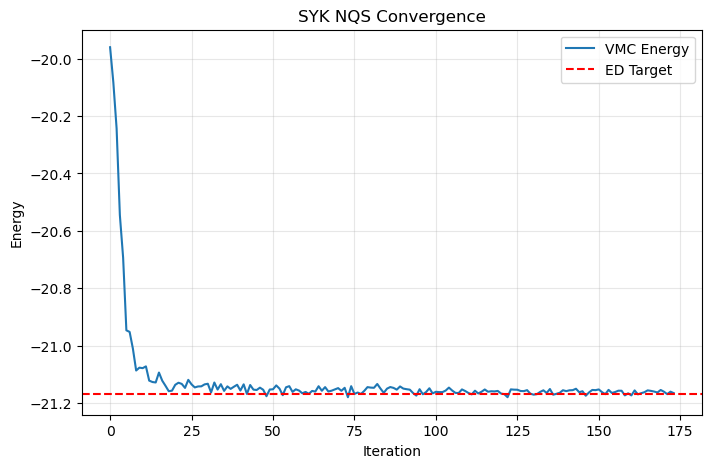

Time taken = 15.62168288230896 (secs)
Current seed_nqs=303
Has 440 parameters


  0%|   | 0/450 [00:00<?, ?it/s, Energy=-19.959 ± 0.069 [σ²=4.7e+00, R̂=1.003]]

Iteration 000: Energy = -19.959015, Var = 4.7354, LR = 5.00e-02


  3%| | 12/450 [00:01<00:38, 11.30it/s, Energy=-21.089 ± 0.018 [σ²=3.1e-01, R̂=

Iteration 010: Energy = -21.113571, Var = 0.3836, LR = 5.00e-02


...


 >>> [LR REDUCTION] Step 108: Energy stalled at -21.157407
 >>> Lowering LR: 1.25e-02 --> 6.25e-03



 25%|▏| 111/450 [00:10<00:39,  8.69it/s, Energy=-21.1436 ± 0.0098 [σ²=9.7e-02, 

Iteration 110: Energy = -21.159726, Var = 0.0899, LR = 6.25e-03


 26%|▎| 118/450 [00:11<00:31, 10.55it/s, Energy=-21.1483 ± 0.0094 [σ²=8.9e-02, 



 >>> [EARLY STOPPING] Step 118: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 018 (Energy: -21.174601)...


Restored best model weights from step 018 (Energy: -21.174601)

Relative error   : 0.00038838461561846726

Mean Energy:        -21.133756
Error Bar:          ± 0.014424
Variance:           0.209726
Final VMC Energy:   -21.148265
Energy per Fermion: -1.056688
Final model weights saved to: qsk_N=20/seed_qsk=1234/seed=303/rbm_alpha=1_ML_final_params.mpack


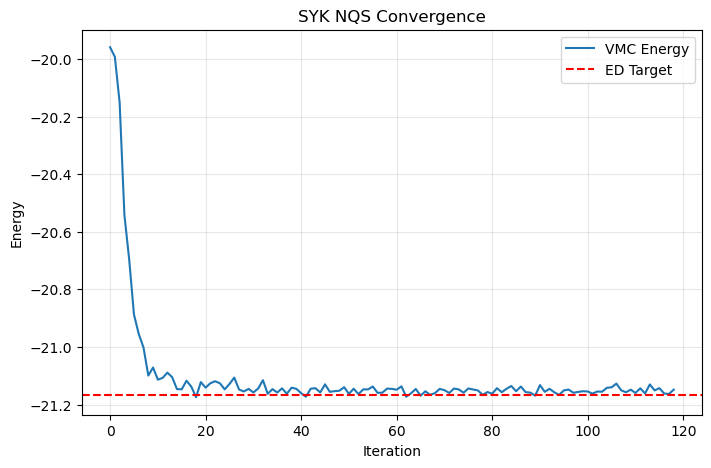

Time taken = 11.510626077651978 (secs)
********************************************************************************
Current seed_qsk=5678
# Loaded state from  sk_20_5678.npy
Exact ED Ground State Energy for seed 5678 is -21.245930
********************************************************************************
Current seed_nqs=101
Has 440 parameters


  0%|   | 0/450 [00:00<?, ?it/s, Energy=-20.001 ± 0.065 [σ²=4.2e+00, R̂=1.011]]

Iteration 000: Energy = -20.000729, Var = 4.2236, LR = 5.00e-02


  2%| | 11/450 [00:01<00:58,  7.45it/s, Energy=-21.193 ± 0.017 [σ²=3.0e-01, R̂=

Iteration 010: Energy = -21.200653, Var = 0.3100, LR = 5.00e-02


...

Iteration 300: Energy = -21.234487, Var = 0.0453, LR = 7.81e-04


 69%|▋| 311/450 [00:36<00:12, 11.40it/s, Energy=-21.2322 ± 0.0066 [σ²=4.4e-02, 

Iteration 310: Energy = -21.241641, Var = 0.0441, LR = 7.81e-04

 >>> [LR REDUCTION] Step 311: Energy stalled at -21.244898
 >>> Lowering LR: 7.81e-04 --> 3.91e-04



 71%|▋| 321/450 [00:37<00:15,  8.52it/s, Energy=-21.2394 ± 0.0069 [σ²=4.8e-02, 


Iteration 320: Energy = -21.236370, Var = 0.0428, LR = 3.91e-04

 >>> [EARLY STOPPING] Step 321: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 221 (Energy: -21.262515)...


Restored best model weights from step 221 (Energy: -21.262515)

Relative error   : 0.0007806131553839198

Mean Energy:        -21.240651
Error Bar:          ± 0.006552
Variance:           0.043269
Final VMC Energy:   -21.239424
Energy per Fermion: -1.062033
Final model weights saved to: qsk_N=20/seed_qsk=5678/seed=101/rbm_alpha=1_ML_final_params.mpack


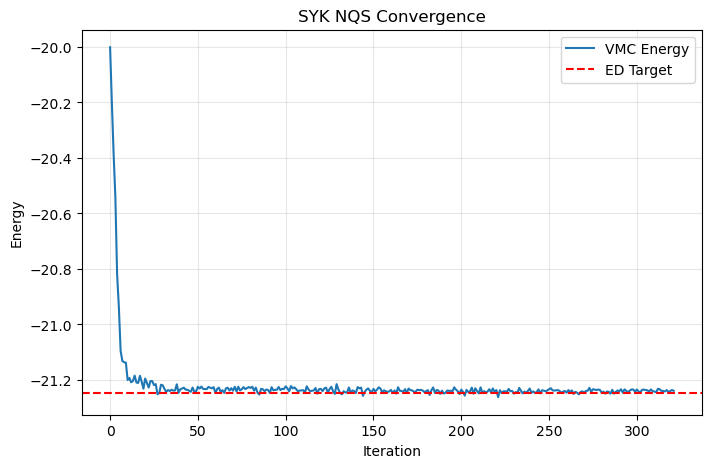

Time taken = 38.51521110534668 (secs)
Current seed_nqs=202
Has 440 parameters


  0%|   | 0/450 [00:00<?, ?it/s, Energy=-19.924 ± 0.068 [σ²=4.7e+00, R̂=1.004]]

Iteration 000: Energy = -19.924226, Var = 4.6535, LR = 5.00e-02


  3%| | 12/450 [00:01<00:42, 10.20it/s, Energy=-21.177 ± 0.016 [σ²=2.7e-01, R̂=

Iteration 010: Energy = -21.141483, Var = 0.3586, LR = 5.00e-02


...


 >>> [LR REDUCTION] Step 143: Energy stalled at -21.252443
 >>> Lowering LR: 1.25e-02 --> 6.25e-03



 34%|▎| 151/450 [00:15<00:35,  8.40it/s, Energy=-21.2414 ± 0.0062 [σ²=3.9e-02, 

Iteration 150: Energy = -21.240934, Var = 0.0421, LR = 6.25e-03


 34%|▎| 153/450 [00:15<00:30,  9.64it/s, Energy=-21.2422 ± 0.0061 [σ²=3.8e-02, 



 >>> [EARLY STOPPING] Step 153: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 053 (Energy: -21.263753)...


Restored best model weights from step 053 (Energy: -21.263753)

Relative error   : 0.0008389005439060546

Mean Energy:        -21.257030
Error Bar:          ± 0.007822
Variance:           0.061674
Final VMC Energy:   -21.242158
Energy per Fermion: -1.062852
Final model weights saved to: qsk_N=20/seed_qsk=5678/seed=202/rbm_alpha=1_ML_final_params.mpack


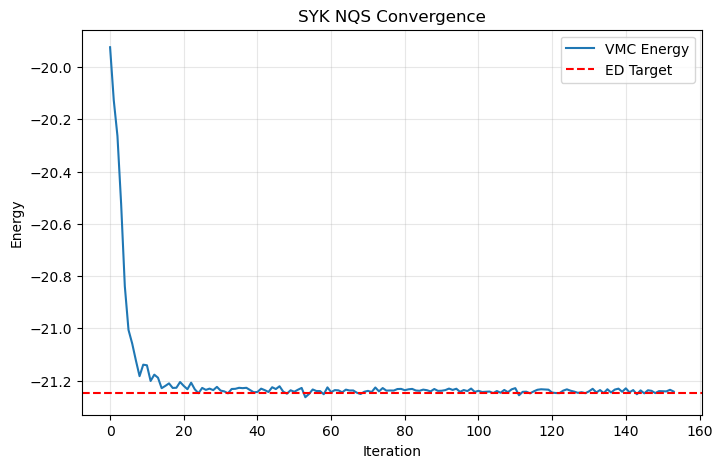

Time taken = 16.343496084213257 (secs)
Current seed_nqs=303
Has 440 parameters


  0%|   | 0/450 [00:00<?, ?it/s, Energy=-19.991 ± 0.066 [σ²=4.3e+00, R̂=1.005]]

Iteration 000: Energy = -19.990982, Var = 4.3373, LR = 5.00e-02


  2%| | 11/450 [00:01<00:47,  9.32it/s, Energy=-21.219 ± 0.017 [σ²=2.9e-01, R̂=

Iteration 010: Energy = -21.179218, Var = 0.3126, LR = 5.00e-02


...

Iteration 140: Energy = -21.249011, Var = 0.0325, LR = 1.25e-02

 >>> [LR REDUCTION] Step 142: Energy stalled at -21.231326
 >>> Lowering LR: 1.25e-02 --> 6.25e-03



 34%|▎| 151/450 [00:16<00:27, 10.86it/s, Energy=-21.2333 ± 0.0053 [σ²=2.9e-02, 

Iteration 150: Energy = -21.248287, Var = 0.0298, LR = 6.25e-03


 34%|▎| 152/450 [00:16<00:32,  9.06it/s, Energy=-21.2416 ± 0.0057 [σ²=3.3e-02, 



 >>> [EARLY STOPPING] Step 152: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 052 (Energy: -21.259027)...


Restored best model weights from step 052 (Energy: -21.259027)

Relative error   : 0.0006164283947445264

Mean Energy:        -21.234992
Error Bar:          ± 0.007662
Variance:           0.059183
Final VMC Energy:   -21.241603
Energy per Fermion: -1.061750
Final model weights saved to: qsk_N=20/seed_qsk=5678/seed=303/rbm_alpha=1_ML_final_params.mpack


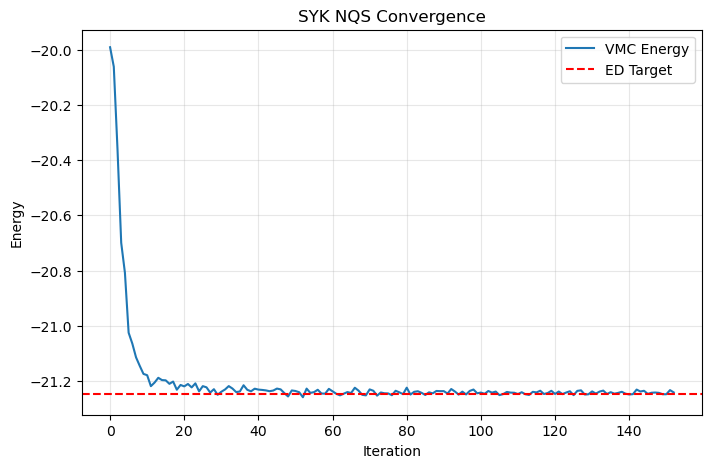

Time taken = 17.291112184524536 (secs)
********************************************************************************
Current seed_qsk=9012
# Loaded state from  sk_20_9012.npy
Exact ED Ground State Energy for seed 9012 is -21.316428
********************************************************************************
Current seed_nqs=101
Has 440 parameters


  0%|   | 0/450 [00:00<?, ?it/s, Energy=-19.977 ± 0.068 [σ²=4.7e+00, R̂=1.009]]

Iteration 000: Energy = -19.976672, Var = 4.6601, LR = 5.00e-02


  3%| | 12/450 [00:01<00:51,  8.45it/s, Energy=-21.250 ± 0.019 [σ²=3.5e-01, R̂=

Iteration 010: Energy = -21.258809, Var = 0.3683, LR = 5.00e-02


...

Iteration 340: Energy = -21.301320, Var = 0.0426, LR = 3.91e-04


 78%|▊| 349/450 [00:36<00:10,  9.72it/s, Energy=-21.2995 ± 0.0063 [σ²=3.9e-02, 


 >>> [LR REDUCTION] Step 349: Energy stalled at -21.319641
 >>> Lowering LR: 3.91e-04 --> 1.95e-04

Iteration 350: Energy = -21.299478, Var = 0.0394, LR = 1.95e-04


 80%|▊| 359/450 [00:36<00:09,  9.73it/s, Energy=-21.3157 ± 0.0065 [σ²=4.3e-02, 



 >>> [EARLY STOPPING] Step 359: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 259 (Energy: -21.326960)...


Restored best model weights from step 259 (Energy: -21.326960)

Relative error   : 0.000494069069781166

Mean Energy:        -21.305150
Error Bar:          ± 0.006640
Variance:           0.044443
Final VMC Energy:   -21.315653
Energy per Fermion: -1.065258
Final model weights saved to: qsk_N=20/seed_qsk=9012/seed=101/rbm_alpha=1_ML_final_params.mpack


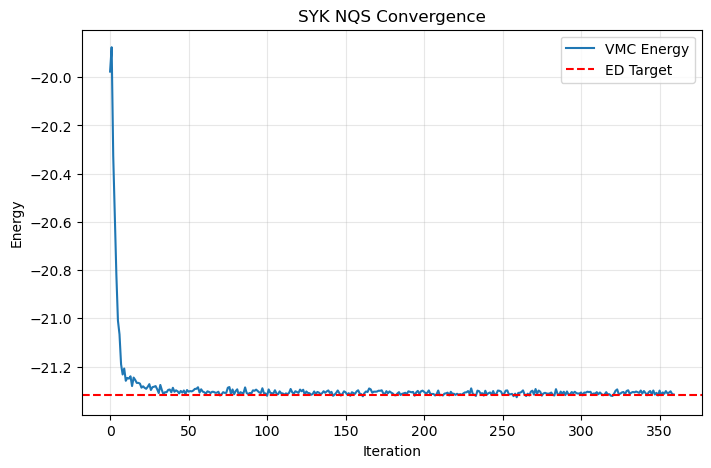

Time taken = 37.53778100013733 (secs)
Current seed_nqs=202
Has 440 parameters


  0%|   | 0/450 [00:00<?, ?it/s, Energy=-19.952 ± 0.072 [σ²=5.3e+00, R̂=1.005]]

Iteration 000: Energy = -19.951829, Var = 5.2761, LR = 5.00e-02


  2%| | 10/450 [00:01<01:01,  7.18it/s, Energy=-21.255 ± 0.018 [σ²=3.3e-01, R̂=

Iteration 010: Energy = -21.259474, Var = 0.3552, LR = 5.00e-02


...

Iteration 130: Energy = -21.313337, Var = 0.0387, LR = 1.25e-02


 31%|▎| 141/450 [00:15<00:35,  8.75it/s, Energy=-21.3169 ± 0.0061 [σ²=3.8e-02, 

Iteration 140: Energy = -21.300296, Var = 0.0382, LR = 1.25e-02

 >>> [LR REDUCTION] Step 141: Energy stalled at -21.315095
 >>> Lowering LR: 1.25e-02 --> 6.25e-03



 34%|▎| 151/450 [00:16<00:33,  8.98it/s, Energy=-21.3109 ± 0.0060 [σ²=3.6e-02, 


Iteration 150: Energy = -21.300094, Var = 0.0385, LR = 6.25e-03

 >>> [EARLY STOPPING] Step 151: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 051 (Energy: -21.329523)...


Restored best model weights from step 051 (Energy: -21.329523)

Relative error   : 0.0006143000457296914

Mean Energy:        -21.309593
Error Bar:          ± 0.009236
Variance:           0.085989
Final VMC Energy:   -21.310870
Energy per Fermion: -1.065480
Final model weights saved to: qsk_N=20/seed_qsk=9012/seed=202/rbm_alpha=1_ML_final_params.mpack


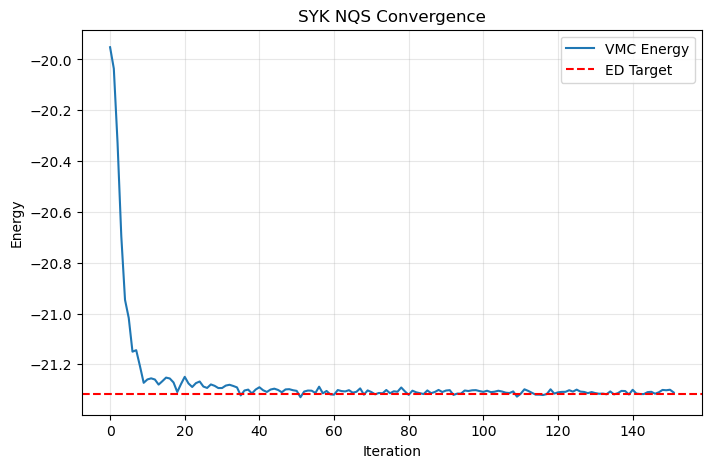

Time taken = 17.19325089454651 (secs)
Current seed_nqs=303
Has 440 parameters


  0%|   | 0/450 [00:00<?, ?it/s, Energy=-19.915 ± 0.070 [σ²=4.9e+00, R̂=1.008]]

Iteration 000: Energy = -19.915118, Var = 4.9454, LR = 5.00e-02


  2%| | 10/450 [00:01<00:43, 10.06it/s, Energy=-21.239 ± 0.019 [σ²=3.7e-01, R̂=

Iteration 010: Energy = -21.239418, Var = 0.3687, LR = 5.00e-02


...


 >>> [LR REDUCTION] Step 205: Energy stalled at -21.312793
 >>> Lowering LR: 6.25e-03 --> 3.13e-03



 47%|▍| 211/450 [00:22<00:22, 10.49it/s, Energy=-21.3147 ± 0.0046 [σ²=2.1e-02, 

Iteration 210: Energy = -21.317283, Var = 0.0200, LR = 3.13e-03


 48%|▍| 215/450 [00:22<00:24,  9.54it/s, Energy=-21.3145 ± 0.0044 [σ²=1.9e-02, 



 >>> [EARLY STOPPING] Step 215: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 115 (Energy: -21.330650)...


Restored best model weights from step 115 (Energy: -21.330650)

Relative error   : 0.0006671667138634147

Mean Energy:        -21.306415
Error Bar:          ± 0.005389
Variance:           0.029272
Final VMC Energy:   -21.314515
Energy per Fermion: -1.065321
Final model weights saved to: qsk_N=20/seed_qsk=9012/seed=303/rbm_alpha=1_ML_final_params.mpack


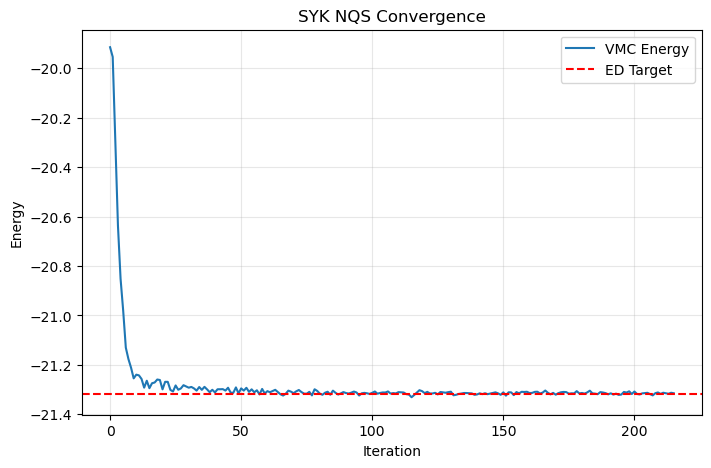

Time taken = 22.888553142547607 (secs)


In [5]:
for seed_qsk in seed_qsk_list:
    print('********************************************************************************')
    print(f'Current seed_qsk={seed_qsk}')
    hamiltonian, H = generate_hamiltonian_sk(N=N, seed=seed_qsk)
    _, ground_state_vec = generate_state_sk(N=N, seed=seed_qsk)
    sp_h = H.to_sparse()
    exact_E = (ground_state_vec.conj().T @ sp_h @ ground_state_vec).real
    print(f"Exact ED Ground State Energy for seed {seed_qsk} is {exact_E:.6f}")
    print('********************************************************************************')
    
    for seed_nqs in seed_nqs_list:
        print(f'Current seed_nqs={seed_nqs}')
        model = nk.models.RBM(alpha=alpha) 
        nqs_training(N, hamiltonian, exact_E, model, lr, alpha, n_samples,  seed_nqs, 'rbm')
        print('===================================================================================')
       

## HRBM

********************************************************************************
Current seed_qsk=1234
# Loaded state from  sk_20_1234.npy
Exact ED Ground State Energy for seed 1234 is -21.166380
********************************************************************************
Current seed_nqs=101
Has 440 parameters


  0%| | 0/450 [00:18<?, ?it/s, Energy=-19.746-0.005j ± 0.072 [σ²=5.3e+00, R̂=1.

Iteration 000: Energy = -19.745530, Var = 5.2544, LR = 5.00e-02


  2%| | 10/450 [00:06<04:18,  1.70it/s, Energy=-21.1426-0.0014j ± 0.0093 [σ²=8.

Iteration 010: Energy = -21.142581, Var = 0.0864, LR = 5.00e-02


...


 >>> [LR REDUCTION] Step 151: Energy stalled at -21.161942
 >>> Lowering LR: 1.25e-02 --> 6.25e-03



 36%|▎| 160/450 [01:32<03:24,  1.42it/s, Energy=-21.1620-0.0027j ± 0.0055 [σ²=3

Iteration 160: Energy = -21.161986, Var = 0.0300, LR = 6.25e-03


 36%|▎| 161/450 [01:33<02:47,  1.72it/s, Energy=-21.1700-0.0026j ± 0.0053 [σ²=2



 >>> [EARLY STOPPING] Step 161: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 061 (Energy: -21.174847)...


Restored best model weights from step 061 (Energy: -21.174847)

Relative error   : 0.0004000387019674307

Mean Energy:        -21.162749
Error Bar:          ± 0.006094
Variance:           0.037431
Final VMC Energy:   -21.170026
Energy per Fermion: -1.058137
Final model weights saved to: qsk_N=20/seed_qsk=1234/seed=101/hrbm_alpha=1_ML_final_params.mpack


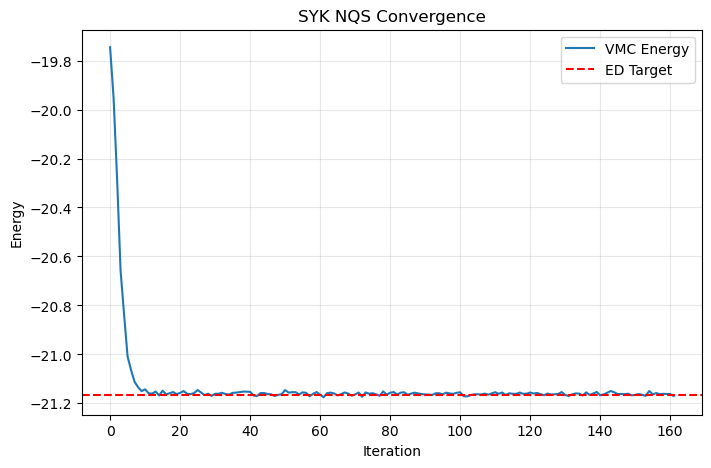

Time taken = 120.4167320728302 (secs)
Current seed_nqs=202
Has 440 parameters


  0%| | 0/450 [00:00<?, ?it/s, Energy=-19.686+0.028j ± 0.072 [σ²=5.2e+00, R̂=1.

Iteration 000: Energy = -19.685971, Var = 5.2389, LR = 5.00e-02


  2%| | 10/450 [00:05<04:24,  1.66it/s, Energy=-21.1682+0.0007j ± 0.0097 [σ²=9.

Iteration 010: Energy = -21.168188, Var = 0.0939, LR = 5.00e-02


...


 >>> [LR REDUCTION] Step 246: Energy stalled at -21.158625
 >>> Lowering LR: 1.56e-03 --> 7.81e-04



 56%|▌| 250/450 [02:21<01:51,  1.80it/s, Energy=-21.1556-0.0069j ± 0.0062 [σ²=3

Iteration 250: Energy = -21.155621, Var = 0.0391, LR = 7.81e-04


 57%|▌| 256/450 [02:25<01:50,  1.76it/s, Energy=-21.1618-0.0009j ± 0.0065 [σ²=4



 >>> [EARLY STOPPING] Step 256: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 156 (Energy: -21.171680)...


Restored best model weights from step 156 (Energy: -21.171680)

Relative error   : 0.0002503866684478595

Mean Energy:        -21.165212
Error Bar:          ± 0.006182
Variance:           0.038518
Final VMC Energy:   -21.161823
Energy per Fermion: -1.058261
Final model weights saved to: qsk_N=20/seed_qsk=1234/seed=202/hrbm_alpha=1_ML_final_params.mpack


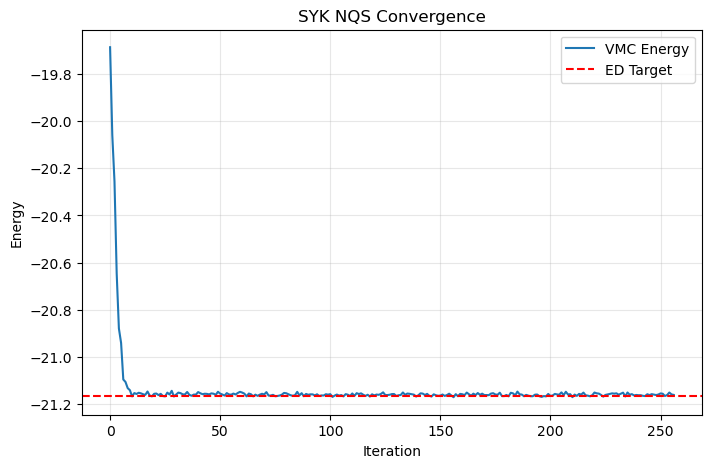

Time taken = 146.27344369888306 (secs)
Current seed_nqs=303
Has 440 parameters


  0%| | 0/450 [00:00<?, ?it/s, Energy=-19.817+0.015j ± 0.069 [σ²=4.8e+00, R̂=1.

Iteration 000: Energy = -19.816614, Var = 4.8269, LR = 5.00e-02


  2%| | 10/450 [00:06<04:37,  1.59it/s, Energy=-21.146+0.002j ± 0.011 [σ²=1.1e-

Iteration 010: Energy = -21.145748, Var = 0.1126, LR = 5.00e-02


...


 >>> [LR REDUCTION] Step 218: Energy stalled at -21.169258
 >>> Lowering LR: 3.13e-03 --> 1.56e-03



 49%|▍| 220/450 [02:13<02:35,  1.48it/s, Energy=-21.1620+0.0067j ± 0.0061 [σ²=3

Iteration 220: Energy = -21.161988, Var = 0.0375, LR = 1.56e-03


 51%|▌| 228/450 [02:18<02:14,  1.65it/s, Energy=-21.1725+0.0023j ± 0.0065 [σ²=4



 >>> [EARLY STOPPING] Step 228: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 128 (Energy: -21.173854)...


Restored best model weights from step 128 (Energy: -21.173854)

Relative error   : 0.0003530958392146839

Mean Energy:        -21.161860
Error Bar:          ± 0.006533
Variance:           0.043025
Final VMC Energy:   -21.172450
Energy per Fermion: -1.058093
Final model weights saved to: qsk_N=20/seed_qsk=1234/seed=303/hrbm_alpha=1_ML_final_params.mpack


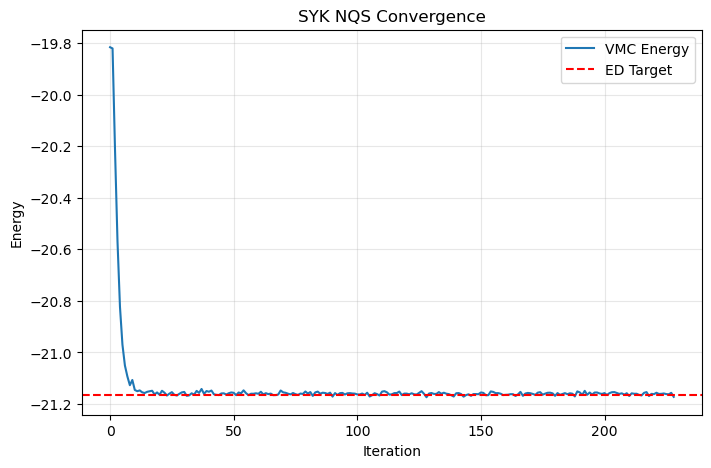

Time taken = 139.2824671268463 (secs)
********************************************************************************
Current seed_qsk=5678
# Loaded state from  sk_20_5678.npy
Exact ED Ground State Energy for seed 5678 is -21.245930
********************************************************************************
Current seed_nqs=101
Has 440 parameters


  0%| | 0/450 [00:00<?, ?it/s, Energy=-19.865-0.005j ± 0.069 [σ²=4.8e+00, R̂=1.

Iteration 000: Energy = -19.865346, Var = 4.7966, LR = 5.00e-02


  2%| | 10/450 [00:04<03:27,  2.12it/s, Energy=-21.2197+0.0053j ± 0.0098 [σ²=9.

Iteration 010: Energy = -21.219731, Var = 0.0966, LR = 5.00e-02


...


 >>> [LR REDUCTION] Step 164: Energy stalled at -21.243053
 >>> Lowering LR: 6.25e-03 --> 3.13e-03



 38%|▍| 170/450 [01:56<03:49,  1.22it/s, Energy=-21.2388-0.0075j ± 0.0060 [σ²=3

Iteration 170: Energy = -21.238800, Var = 0.0361, LR = 3.13e-03


 39%|▍| 174/450 [01:59<03:09,  1.46it/s, Energy=-21.2516-0.0014j ± 0.0061 [σ²=3



 >>> [EARLY STOPPING] Step 174: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 074 (Energy: -21.255219)...


Restored best model weights from step 074 (Energy: -21.255219)

Relative error   : 0.0004371804778205067

Mean Energy:        -21.234628
Error Bar:          ± 0.006629
Variance:           0.044291
Final VMC Energy:   -21.251616
Energy per Fermion: -1.061731
Final model weights saved to: qsk_N=20/seed_qsk=5678/seed=101/hrbm_alpha=1_ML_final_params.mpack


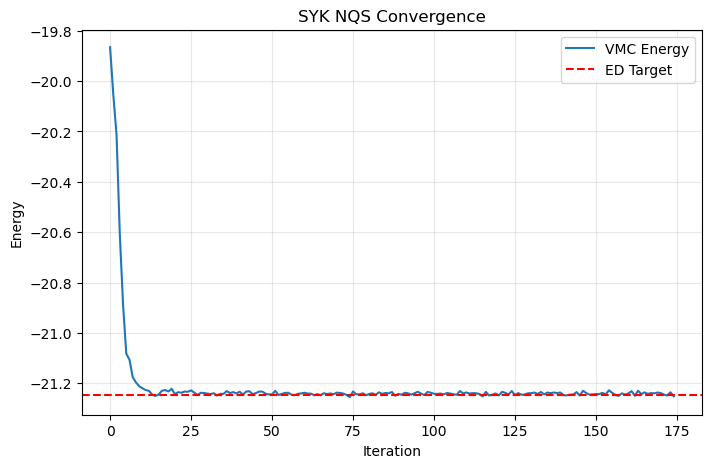

Time taken = 120.6452579498291 (secs)
Current seed_nqs=202
Has 440 parameters


  0%| | 0/450 [00:00<?, ?it/s, Energy=-19.899+0.028j ± 0.070 [σ²=4.9e+00, R̂=1.

Iteration 000: Energy = -19.898930, Var = 4.8807, LR = 5.00e-02


  2%| | 10/450 [00:04<03:24,  2.15it/s, Energy=-21.2273-0.0041j ± 0.0100 [σ²=1.

Iteration 010: Energy = -21.227327, Var = 0.1001, LR = 5.00e-02


...


 >>> [LR REDUCTION] Step 206: Energy stalled at -21.245024
 >>> Lowering LR: 3.13e-03 --> 1.56e-03



 47%|▍| 210/450 [02:43<02:17,  1.75it/s, Energy=-21.2418-0.0003j ± 0.0058 [σ²=3

Iteration 210: Energy = -21.241787, Var = 0.0337, LR = 1.56e-03


 48%|▍| 216/450 [02:46<03:00,  1.30it/s, Energy=-21.2374+0.0009j ± 0.0061 [σ²=3



 >>> [EARLY STOPPING] Step 216: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 116 (Energy: -21.252651)...


Restored best model weights from step 116 (Energy: -21.252651)

Relative error   : 0.00031635299964644944

Mean Energy:        -21.236941
Error Bar:          ± 0.005880
Variance:           0.034848
Final VMC Energy:   -21.237379
Energy per Fermion: -1.061847
Final model weights saved to: qsk_N=20/seed_qsk=5678/seed=202/hrbm_alpha=1_ML_final_params.mpack


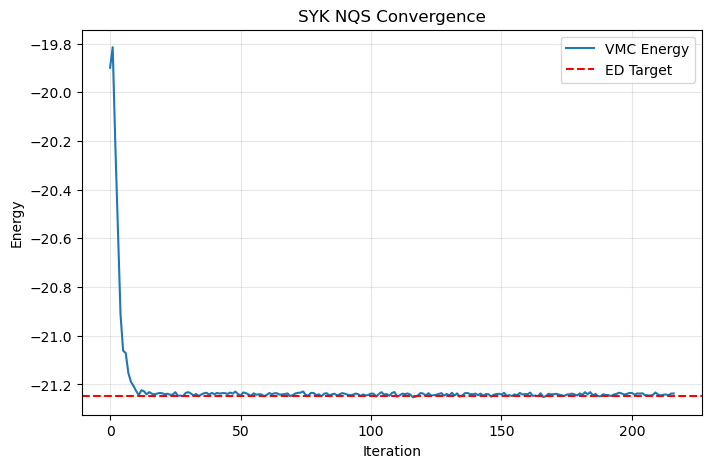

Time taken = 167.3578770160675 (secs)
Current seed_nqs=303
Has 440 parameters


  0%| | 0/450 [00:00<?, ?it/s, Energy=-19.865+0.015j ± 0.071 [σ²=5.1e+00, R̂=1.

Iteration 000: Energy = -19.865457, Var = 5.0652, LR = 5.00e-02


  2%| | 10/450 [00:04<03:38,  2.01it/s, Energy=-21.2268+0.0001j ± 0.0092 [σ²=8.

Iteration 010: Energy = -21.226790, Var = 0.0854, LR = 5.00e-02


...


 >>> [LR REDUCTION] Step 103: Energy stalled at -21.239183
 >>> Lowering LR: 1.25e-02 --> 6.25e-03



 24%|▏| 110/450 [01:12<04:15,  1.33it/s, Energy=-21.2412-0.0031j ± 0.0061 [σ²=3

Iteration 110: Energy = -21.241215, Var = 0.0373, LR = 6.25e-03


 25%|▎| 113/450 [01:15<03:45,  1.50it/s, Energy=-21.2364-0.0053j ± 0.0062 [σ²=3



 >>> [EARLY STOPPING] Step 113: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 013 (Energy: -21.252825)...


Restored best model weights from step 013 (Energy: -21.252825)

Relative error   : 0.00032454297780258265

Mean Energy:        -21.227476
Error Bar:          ± 0.007916
Variance:           0.063158
Final VMC Energy:   -21.236434
Energy per Fermion: -1.061374
Final model weights saved to: qsk_N=20/seed_qsk=5678/seed=303/hrbm_alpha=1_ML_final_params.mpack


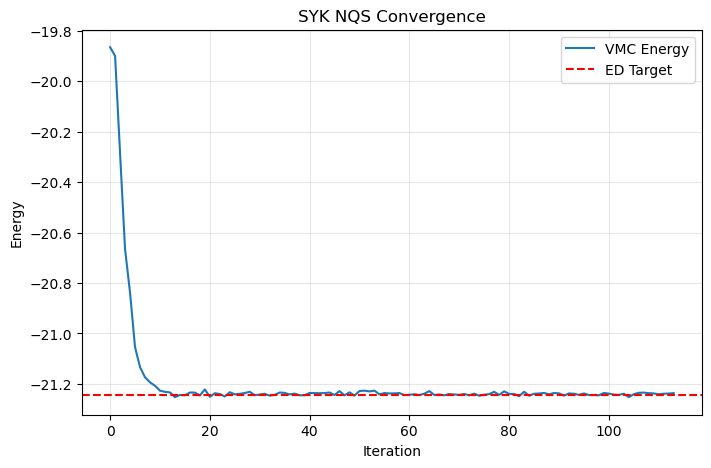

Time taken = 76.71574807167053 (secs)
********************************************************************************
Current seed_qsk=9012
# Loaded state from  sk_20_9012.npy
Exact ED Ground State Energy for seed 9012 is -21.316428
********************************************************************************
Current seed_nqs=101
Has 440 parameters


  0%| | 0/450 [00:00<?, ?it/s, Energy=-19.908-0.005j ± 0.071 [σ²=5.0e+00, R̂=1.

Iteration 000: Energy = -19.907878, Var = 5.0184, LR = 5.00e-02


  2%| | 10/450 [00:06<03:58,  1.85it/s, Energy=-21.323+0.002j ± 0.011 [σ²=1.1e-

Iteration 010: Energy = -21.322858, Var = 0.1122, LR = 5.00e-02


...

Iteration 130: Energy = -21.308364, Var = 0.0420, LR = 6.25e-03


 31%|▎| 140/450 [01:43<05:47,  1.12s/it, Energy=-21.3175-0.0037j ± 0.0066 [σ²=4

Iteration 140: Energy = -21.317495, Var = 0.0434, LR = 6.25e-03

 >>> [LR REDUCTION] Step 140: Energy stalled at -21.317495
 >>> Lowering LR: 6.25e-03 --> 3.13e-03



 33%|▎| 150/450 [01:52<03:44,  1.33it/s, Energy=-21.3186+0.0018j ± 0.0062 [σ²=3


Iteration 150: Energy = -21.318633, Var = 0.0391, LR = 3.13e-03

 >>> [EARLY STOPPING] Step 150: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 050 (Energy: -21.324240)...


Restored best model weights from step 050 (Energy: -21.324240)

Relative error   : 0.00036644813262802316

Mean Energy:        -21.303689
Error Bar:          ± 0.006786
Variance:           0.046420
Final VMC Energy:   -21.318633
Energy per Fermion: -1.065184
Final model weights saved to: qsk_N=20/seed_qsk=9012/seed=101/hrbm_alpha=1_ML_final_params.mpack


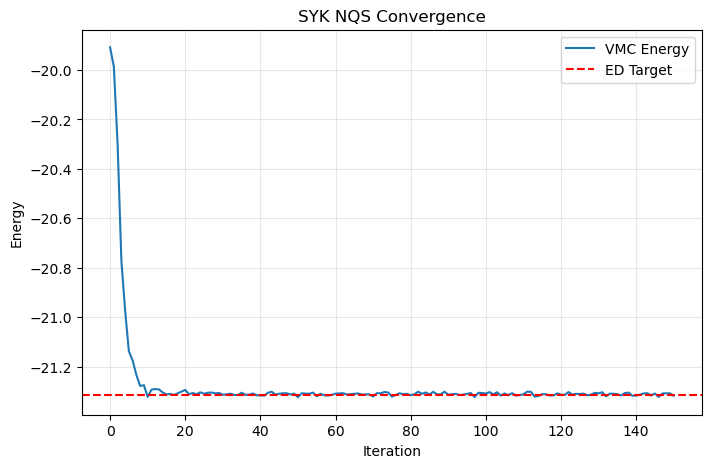

Time taken = 113.51130795478821 (secs)
Current seed_nqs=202
Has 440 parameters


  0%| | 0/450 [00:00<?, ?it/s, Energy=-19.644+0.028j ± 0.074 [σ²=5.5e+00, R̂=1.

Iteration 000: Energy = -19.644459, Var = 5.4913, LR = 5.00e-02


  2%| | 10/450 [00:07<06:26,  1.14it/s, Energy=-21.301+0.001j ± 0.010 [σ²=1.0e-

Iteration 010: Energy = -21.301347, Var = 0.1044, LR = 5.00e-02


...


 >>> [LR REDUCTION] Step 145: Energy stalled at -21.313888
 >>> Lowering LR: 1.25e-02 --> 6.25e-03



 33%|▎| 150/450 [02:09<04:39,  1.07it/s, Energy=-21.3128+0.0002j ± 0.0064 [σ²=4

Iteration 150: Energy = -21.312796, Var = 0.0410, LR = 6.25e-03


 34%|▎| 155/450 [02:14<04:16,  1.15it/s, Energy=-21.3101-0.0013j ± 0.0060 [σ²=3



 >>> [EARLY STOPPING] Step 155: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 055 (Energy: -21.323464)...


Restored best model weights from step 055 (Energy: -21.323464)

Relative error   : 0.00033006972377456025

Mean Energy:        -21.302979
Error Bar:          ± 0.007163
Variance:           0.051715
Final VMC Energy:   -21.310130
Energy per Fermion: -1.065149
Final model weights saved to: qsk_N=20/seed_qsk=9012/seed=202/hrbm_alpha=1_ML_final_params.mpack


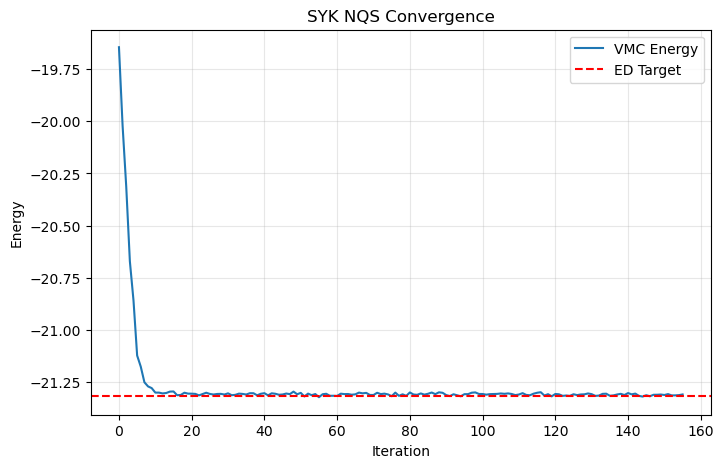

Time taken = 135.99847507476807 (secs)
Current seed_nqs=303
Has 440 parameters


  0%| | 0/450 [00:00<?, ?it/s, Energy=-19.864+0.015j ± 0.074 [σ²=5.6e+00, R̂=1.

Iteration 000: Energy = -19.863626, Var = 5.5687, LR = 5.00e-02


  2%| | 9/450 [00:09<06:47,  1.08it/s, Energy=-21.287+0.009j ± 0.010 [σ²=1.0e-0

Iteration 010: Energy = -21.287170, Var = 0.1009, LR = 5.00e-02


...


 >>> [LR REDUCTION] Step 255: Energy stalled at -21.314520
 >>> Lowering LR: 1.56e-03 --> 7.81e-04



 58%|▌| 260/450 [03:36<01:53,  1.68it/s, Energy=-21.3121-0.0061j ± 0.0063 [σ²=4

Iteration 260: Energy = -21.312068, Var = 0.0405, LR = 7.81e-04


 59%|▌| 265/450 [03:38<02:32,  1.21it/s, Energy=-21.3089-0.0014j ± 0.0057 [σ²=3



 >>> [EARLY STOPPING] Step 265: No energy improvement over last 100 steps.
 >>> Restoring best parameters from step 165 (Energy: -21.329981)...


Restored best model weights from step 165 (Energy: -21.329981)

Relative error   : 0.000635789509160144

Mean Energy:        -21.318439
Error Bar:          ± 0.006474
Variance:           0.042248
Final VMC Energy:   -21.308875
Energy per Fermion: -1.065922
Final model weights saved to: qsk_N=20/seed_qsk=9012/seed=303/hrbm_alpha=1_ML_final_params.mpack


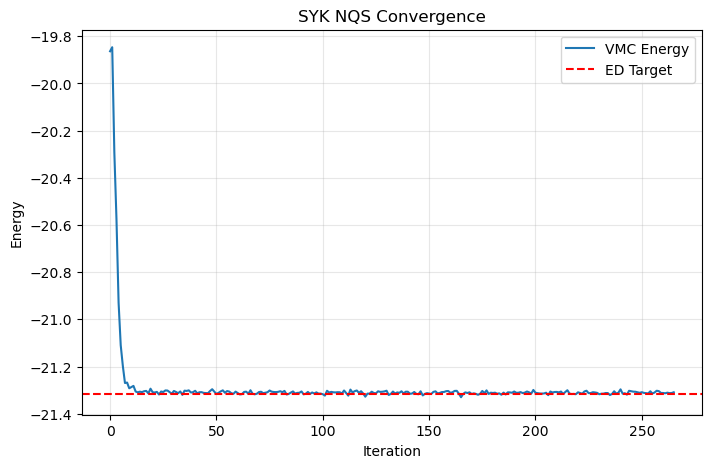

Time taken = 220.02037382125854 (secs)


In [7]:
k=1.0
Lmax=10
for seed_qsk in seed_qsk_list:
    print('********************************************************************************')
    print(f'Current seed_qsk={seed_qsk}')
    hamiltonian, H = generate_hamiltonian_sk(N=N, seed=seed_qsk)
    _, ground_state_vec = generate_state_sk(N=N, seed=seed_qsk)
    sp_h = H.to_sparse()
    exact_E = (ground_state_vec.conj().T @ sp_h @ ground_state_vec).real
    print(f"Exact ED Ground State Energy for seed {seed_qsk} is {exact_E:.6f}")
    print('********************************************************************************')
    
    for seed_nqs in seed_nqs_list:
        print(f'Current seed_nqs={seed_nqs}')
        model = HyperbolicRBM(alpha=alpha, k=k, Lmax=Lmax)
        nqs_training(N, hamiltonian, exact_E, model, lr, alpha, n_samples, seed_nqs, 'hrbm')
        print('===================================================================================')